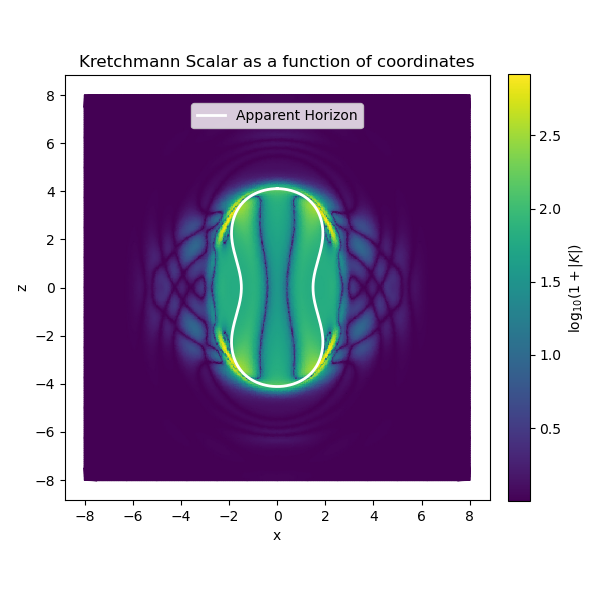

In [9]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
# =========================
# 1. LOAD CSV
# =========================
data = np.loadtxt("/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.113_4.113/brill_twist_zsymmetric_4.113_4.113_200_100_2_2d/output_2d/xz/ana.CSI/prv.csv", delimiter=",", skiprows=1)

x = data[:, 2]   # Points:0
z = data[:, 4]   # Points:2
csi = data[:, 0] # ana.CSI

# =========================
# 2. LOG SCALING
# =========================
csi_plot = np.log10(1 + np.abs(csi))

# =========================
# 3. PLOT FIELD
# =========================
plt.figure(figsize=(6,6))

# Use tricontourf (works for unstructured points)
cf = plt.tripcolor(x, z, csi_plot, shading='gouraud', cmap='viridis')

# =========================
# 4. HORIZON
# =========================
horizon = np.loadtxt("/home/ashiquetnizar/Projects/Reps/cc_axi/findAH/horizon_4.113_hdwg_108000.bin.txt", skiprows=1)
plt.plot(horizon[:,0], horizon[:,1], color='white', linewidth=2,label="Apparent Horizon")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95))
# =========================
# 5. AXES
# =========================
plt.xlabel("x")
plt.ylabel("z")
plt.gca().set_aspect('equal')

# Center axes (optional)
# =========================
# 5. AXES (NORMAL, SQUARE)
# =========================
ax = plt.gca()

# Remove centered axes (your current lines → DELETE them)
# ax.spines['left'].set_position('zero')
# ax.spines['bottom'].set_position('zero')

# Keep normal box
ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

plt.xlabel("x")
plt.ylabel("z")

# Equal aspect (square)
ax.set_aspect('equal', adjustable='box')

# =========================
# 6. COLORBAR
# =========================
# =========================
# 6. COLORBAR (MATCH HEIGHT)
# =========================
# =========================
# 6. COLORBAR (CORRECT)
# =========================
fig = plt.gcf()
ax = plt.gca()

cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\log_{10}(1 + |K|)$')

# =========================
# 7. SAVE
# =========================
plt.tight_layout()
plt.title("Kretchmann Scalar as a function of coordinates")
plt.savefig("figure.pdf", dpi=600)

plt.show()



In [8]:
import numpy as np
import plotly.graph_objects as go

# ===== Load data from file =====
filename = "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.107_4.107/brill_twist_zsymmetric_4.107_4.107_200_100_2d/output_0d/origin/ana.alpha.prop.t"   # <-- put your file name here
data = np.loadtxt(filename)

# ===== Extract columns =====
proper_time = data[:, 0]
kretschmann = data[:, 1]

# ===== Compute log(abs(K)) =====
log_k = np.log(np.abs(kretschmann) + 1e-15)  # avoid log(0)
slow_time= -np.log(7.9-proper_time)

# ===== Plot =====
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=proper_time,
    y=log_k,
    mode='lines+markers',
    name='log|Kretschmann|'
))

fig.update_layout(
    title=f"log(|Kretschmann|) vs Proper Time ({filename})",
    xaxis_title="Proper Time",
    yaxis_title="log(|Kretschmann|)",
)

fig.show()

/home/ashiquetnizar/miniconda3/envs/nrgw/lib/python3.6/site-packages/ipykernel_launcher.py:14: RuntimeWarning:

invalid value encountered in log



In [59]:
import numpy as np
import plotly.graph_objects as go

# ===== Load data from file =====
filename = "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.107_4.107/brill_twist_zsymmetric_4.107_4.107_200_100_2d/output_0d/origin/ana.alpha.prop.t"   # <-- put your file name here
data = np.loadtxt(filename)

# ===== Extract columns =====
proper_time = data[:, 0]
kretschmann = data[:, 1]

# ===== Compute log(abs(K)) =====
log_k = np.log(np.abs(kretschmann) + 1e-15)  # avoid log(0)


# ===== Plot =====
fig = go.Figure()
slow_time= -np.log(10.2-proper_time)
fig.add_trace(go.Scatter(
    x=slow_time,
    y=log_k,
    mode='lines+markers',
    name='log|Kretschmann|'
))

fig.update_layout(
    title=f"log(|Kretschmann|) vs Proper Time ({filename})",
    xaxis_title="Proper Time",
    yaxis_title="log(|Kretschmann|)",
)

fig.show()

/home/ashiquetnizar/miniconda3/envs/nrgw/lib/python3.6/site-packages/ipykernel_launcher.py:18: RuntimeWarning:

invalid value encountered in log



In [6]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

# Force clean rendering (avoids duplicate plots)
pio.renderers.default = "browser"

# ===== Load data =====
filename = "/media/ashiquetnizar/BA78F8F778F8B36D/Common/Data_Cluster_transfer/A4.107_4.107/brill_twist_zsymmetric_4.107_4.107_200_100_2d/output_0d/origin/ana.alpha.prop.t"
data = np.loadtxt(filename)

proper_time = data[:, 0]
kretschmann = data[:, 1]

# log(|K|)
log_k = np.log(np.abs(kretschmann) + 1e-15)

# ===== t* range =====
t_star_values = np.arange(7,13, 0.5)

# ===== Precompute ONLY physical branch (τ < t*) =====
slow_time_all = []
log_k_all = []

for t in t_star_values:
    mask = proper_time < t   # 👈 CRUCIAL FIX
    
    tau_valid = proper_time[mask]
    k_valid = log_k[mask]
    
    slow_time = -np.log(t - tau_valid)
    
    slow_time_all.append(slow_time)
    log_k_all.append(k_valid)

# ===== Create figure =====
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=slow_time_all[0],
    y=log_k_all[0],
    mode='lines',
    name='log|K|'
))

# ===== Slider =====
steps = []
for i, t in enumerate(t_star_values):
    steps.append(dict(
        method="restyle",
        args=[{
            "x": [slow_time_all[i]],
            "y": [log_k_all[i]]
        }, [0]],
        label=f"{t:.1f}"
    ))

fig.update_layout(
    sliders=[dict(
        active=0,
        currentvalue={"prefix": "t*: "},
        steps=steps
    )],
    title="log(|Kretschmann|) vs Slow Time",
    xaxis_title="Slow time = -log(t* - τ)",
    yaxis_title="log(|Kretschmann|)"
)

print("Number of traces:", len(fig.data))  # should be 1

fig.show()

Number of traces: 1
